In [1]:
from pathlib import Path
from functools import partial
import polars as pl
from matplotlib import pyplot as plt
import numpy as np

import matplotlib as mpl
from matplotlib.ticker import AutoMinorLocator
from matplotlib_config import rcparams
mpl.rcParams.update(rcparams)

In [2]:
df_red_noise_parameters = pl.read_parquet(
    '../results/gaia_qso_initial_selection_40obs_500d/red_noise_laplace/'
)

vi_params = df_red_noise_parameters.select(['vi_params']).with_columns(pl.col('vi_params').cast(pl.Array(pl.Float64, 3))).to_series().to_numpy()
log10_sigma = (np.exp(vi_params[:, 1])) #* np.sqrt(2))
log10_tau = (np.exp(vi_params[:, 2]))

df_candidates_mcmc = pl.read_csv('../results/final_candidate_list.csv')

Text(0, 0.5, '$\\tau [days]$')

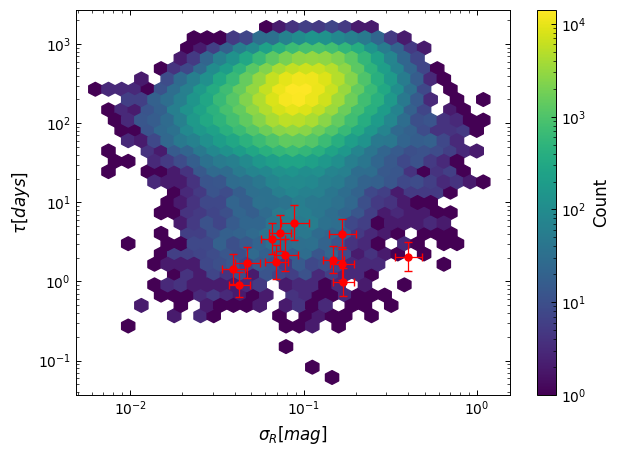

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
hb = ax.hexbin(
    log10_sigma, log10_tau,
    xscale='log', yscale='log', gridsize=30, bins='log', cmap='viridis', mincnt=1
)

sigma_med, tau_med, sigma_lower, sigma_upper, tau_lower, tau_upper = df_candidates_mcmc.select(['sigma_med', 'tau_med', 'sigma_lower', 'sigma_upper', 'tau_lower', 'tau_upper']).to_numpy().T
ax.errorbar(
    sigma_med, tau_med,
    yerr=[tau_lower, tau_upper],
    xerr=[sigma_lower, sigma_upper],
    fmt='o', capsize=3, color='r', ecolor='red', markersize=5
)

fig.colorbar(hb, ax=ax, label='Count')
ax.set_xlabel(r'$\sigma_R [mag]$')
ax.set_ylabel(r'$\tau [days]$')
# fig.savefig('figures/tau_sigma.pdf', bbox_inches='tight', dpi=300)

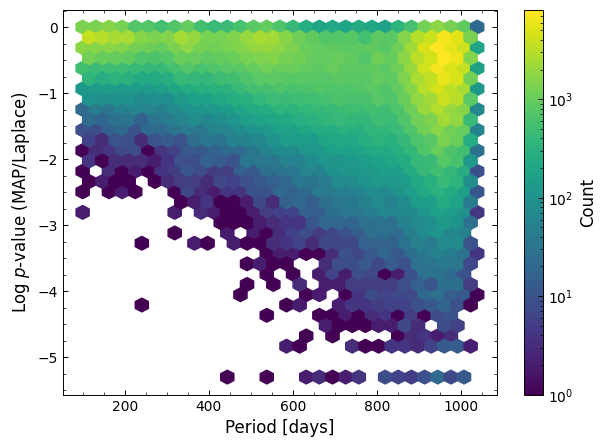

In [4]:
fbin = 0 
experiment = 'gaia_qso_initial_selection_40obs_500d'
significance = 1e-5
result_folder = Path('../results/') / experiment

P, fap_baluev, fap_red = pl.scan_parquet(result_folder / 'periodogram_maxima').join(
    pl.scan_parquet(result_folder / 'pval_mc_laplace'), on='sourceid'
).with_columns(
    (1.0/pl.col('top_frequency').list.get(fbin)).alias('dominant_period'),
    (pl.col('top_fap').list.get(fbin)).alias('fap_baluev'),
    (pl.col('p_values').list.get(fbin)).alias('fap_red')
).select(['dominant_period', 'fap_baluev', 'fap_red']).collect().to_numpy().T

fig, ax = plt.subplots(figsize=(7, 5))
hb = ax.hexbin(P, np.log10(fap_red),
               gridsize=30, bins='log',
               cmap='viridis', mincnt=1)
ax.set_xlabel('Period [days]')
ax.set_ylabel(r'Log $p$-value (MAP/Laplace)')
ax.xaxis.set_minor_locator(AutoMinorLocator(4))
ax.yaxis.set_minor_locator(AutoMinorLocator(4))
fig.colorbar(hb, ax=ax, label='Count')
# fig.savefig('new_plots/p_values.pdf', bbox_inches='tight', dpi=300)